<a href="https://colab.research.google.com/github/gusti-amber/udemy_pytorch/blob/main/lecture/lec5_image_generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RNNによる画像生成
画像を時系列のデータと捉えることで、RNNにより画像を生成できる。
今回は画像データを使ってRNNを訓練し、画像の上半分をもとに画像の下半分を生成する。
RNNの層にはLSTMを使用する。

# 1. Fashion-MNISTの読み込み
torchvision.datasetsを使い、Fashion-MNISTを読み込む。
Fashion-MNISTは、6万枚のファッションアイテム画像にラベルをつけたたデータセットである。
以下のコードでは、Fashion-MNISTを読み込みランダムな25枚の画像を表示する。

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 182kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.42MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 27.2MB/s]


データの数: 60000


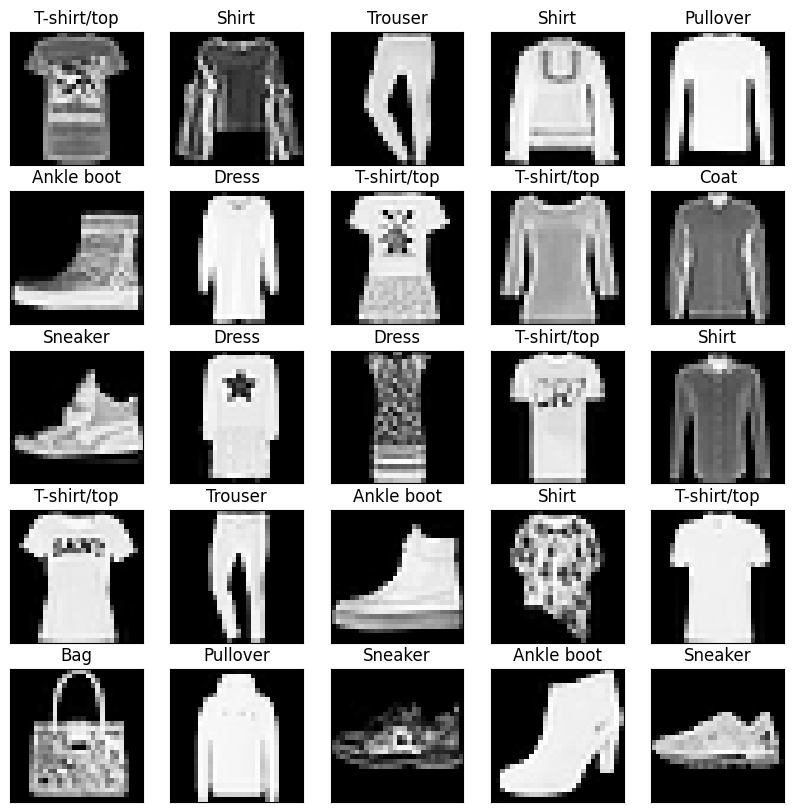

In [1]:
from torchvision.datasets import FashionMNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

# Fashion-MNISTの読み込み
fmnist_data = FashionMNIST(root="./data",
                            train=True,download=True,
                            transform=transforms.ToTensor())
fmnist_classes = np.array(["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
                            "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"])
print("データの数:", len(fmnist_data))

# ミニバッチの取得
n_image = 25  # 表示する画像数
fmnist_loader = DataLoader(fmnist_data, batch_size=n_image, shuffle=True) # データローダーの設定
dataiter = iter(fmnist_loader) # イテレータの設定
images, labels = next(dataiter) # 最初のバッチを取り出す

# ミニバッチの画像群の表示
img_size = 28 # 画像サイズ
plt.figure(figsize=(10,10)) # 画像の表示サイズ
for i in range(n_image):
    plt.subplot(5,5,i+1)

    # 画像の表示
    plt.imshow(images[i].reshape(img_size, img_size), cmap="Greys_r")

    # ラベルの表示
    label = fmnist_classes[labels[i]]
    plt.title(label)

    # ラベルとメモリを非表示
    plt.tick_params(labelbottom=False, labelleft=False, bottom=False, left=False)

plt.show()

# 2. データの前処理
画像データをRNNに適した形に整える。
画像を時系列データに変換するが、正解は時系列の次の行にする。

In [2]:
import torch
from torch.utils.data import DataLoader

n_time = 14 # 時系列の数
n_in = img_size # 入力層のニューロン数
n_mid = 256 # 中間層のニューロン数
n_out = img_size # 出力層のニューロン数
n_sample_in_img = img_size-n_time # 1枚の画像中のサンプル数

# Fashion-MNISTをすべて読み込み
dataloader = DataLoader(fmnist_data, batch_size=len(fmnist_data), shuffle=False)
dataiter = iter(dataloader)
train_imgs, labels = next(dataiter)

# reshape: torch.Size([60000, 1, 28, 28]) → torch.Size([60000, 28, 28])
train_imgs = train_imgs.reshape(-1, img_size, img_size)

n_sample = len(train_imgs) * n_sample_in_img # すべての画像のサンプル数

# 入力・正解データの初期化
input_data = np.zeros((n_sample, n_time, n_in))  # 入力
correct_data = np.zeros((n_sample, n_out))  # 正解

# 入力・正解データの作成
for i in range(len(train_imgs)):
  for j in range(n_sample_in_img):
    sample_id = i*n_sample_in_img + j
    input_data[sample_id] = train_imgs[i,j:j+n_time] # 時系列数分のデータ
    correct_data[sample_id] = train_imgs[i,j+n_time] # 時系列数+1のデータ

# カスタムデータセットの作成
input_data = torch.tensor(input_data, dtype=torch.float)
correct_data = torch.tensor(correct_data, dtype=torch.float)
dataset = torch.utils.data.TensorDataset(input_data, correct_data)

# DataLoaderの設定
train_loader = DataLoader(dataset, batch_size=128, shuffle=True)

/tmp/ipython-input-429407083.py:28: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  input_data[sample_id] = train_imgs[i,j:j+n_time] # 時系列数分のデータ
/tmp/ipython-input-429407083.py:29: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  correct_data[sample_id] = train_imgs[i,j+n_time] # 時系列数+1のデータ


# 3. テスト用データの作成
訓練済みのモデルが機能することを確めるために使用する。

In [4]:
n_disp = 10  # 生成し表示する画像の数

# Fashion-MNISTからテストデータの読み込み
disp_data = FashionMNIST(root="./data",
                            train=False,download=True,
                            transform=transforms.ToTensor())

# テストデータから画像を10枚取り出す
disp_loader = DataLoader(disp_data, batch_size=n_disp, shuffle=False)
dataiter = iter(disp_loader)
disp_imgs, labels = next(dataiter)
disp_imgs = disp_imgs.reshape(-1, img_size, img_size)


# 4. 画像生成関数の定義
画像生成関数を定義し、オリジナル画像disp_imgsと、オリジナル画像の上半分をもとに下半分を生成したgen_imgsを並べて表示する。

最初は画像の上半分をシードにして新たな行を生成するが、次はその新たな行を含む直近の時系列からさらに次の行を生成する。

これを繰り返すことで下半分の画像が生成される。

In [8]:
def generate_images():
    # オリジナルの画像
    print("Original:")
    plt.figure(figsize=(20, 2))

    for i in range(n_disp):
        ax = plt.subplot(1, n_disp, i+1)
        plt.imshow(disp_imgs[i], cmap="Greys_r", vmin=0.0, vmax=1.0)
        ax.get_xaxis().set_visible(False)  # 軸を非表示に
        ax.get_yaxis().set_visible(False)
    plt.show()

    # 下半分をRNNにより生成した画像
    print("Generated:")
    gen_imgs = disp_imgs.clone()
    plt.figure(figsize=(20, 2))

    for i in range(n_disp):
        # RNNによる画像生成
        for j in range(n_sample_in_img):
            x = gen_imgs[i, j:j+n_time].reshape(1, n_time, img_size)
            x = x.cuda()  # GPU対応
            gen_imgs[i, j+n_time] = net(x)[0] # 時系列+1を生成

        ax = plt.subplot(1, n_disp, i+1)
        plt.imshow(gen_imgs[i].detach(), cmap="Greys_r", vmin=0.0, vmax=1.0)
        ax.get_xaxis().set_visible(False)  # 軸を非表示に
        ax.get_yaxis().set_visible(False)
    plt.show()

# 5. モデルの構築


In [5]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.LSTM(  # LSTM層
            input_size=n_in,  # 入力サイズ
            hidden_size=n_mid,  # ニューロン数
            batch_first=True,  # 入力を (バッチサイズ, 時系列の数, 入力の数) にする
        )
        self.fc = nn.Linear(n_mid, n_out)  # 全結合層

    def forward(self, x):
        y_rnn, (h, c) = self.rnn(x, None)  # hは次の時刻に渡される値、 cは記憶セル
        y = self.fc(y_rnn[:, -1, :])  # yは最後の時刻の出力
        return y

net = Net()
net.cuda()  # GPU対応
print(net)

Net(
  (rnn): LSTM(28, 256, batch_first=True)
  (fc): Linear(in_features=256, out_features=28, bias=True)
)


# 6. 学習
DataLoaderを使い、ミニバッチを取り出して訓練および評価を行う。

学習中、一定のエポック間隔ごとに誤差の表示と画像の生成が行われる。

Epoch: 0 Loss_Train: 0.008857728955997901
Original:


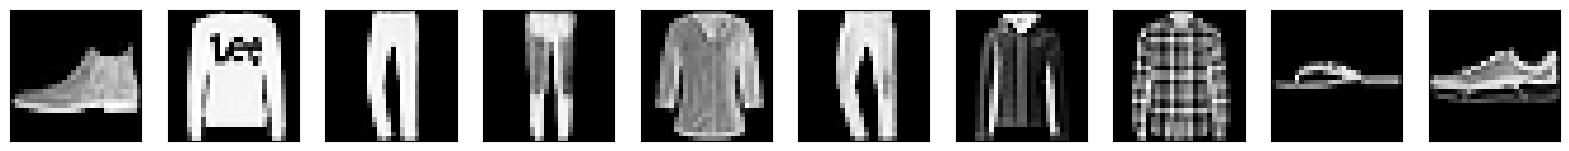

Generated:


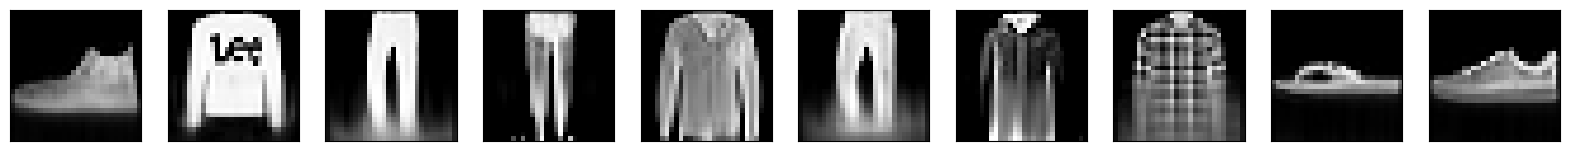

Epoch: 1 Loss_Train: 0.00880774294762541
Original:


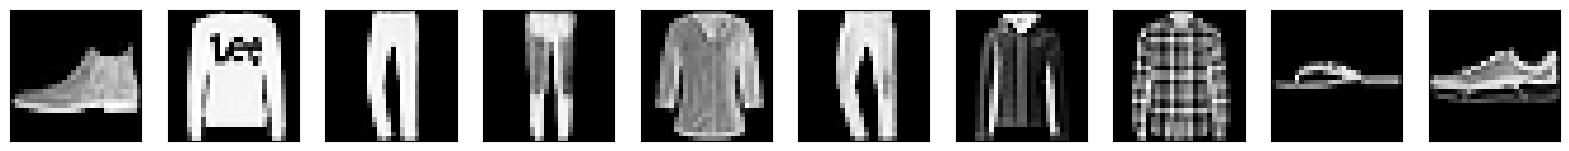

Generated:


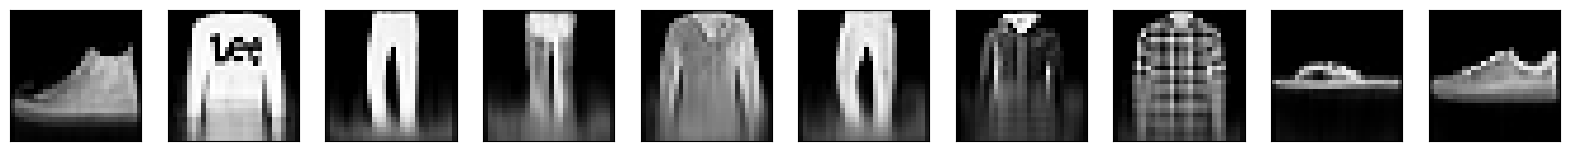

Epoch: 2 Loss_Train: 0.00874970378443592
Original:


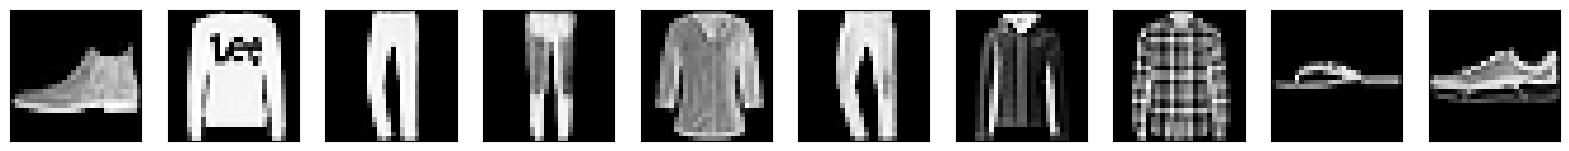

Generated:


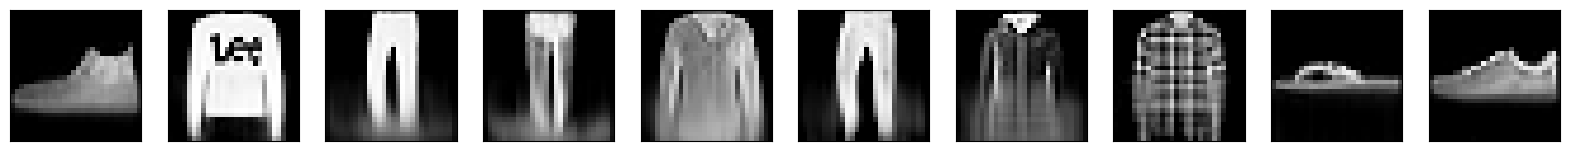

Epoch: 3 Loss_Train: 0.00870488354928863
Original:


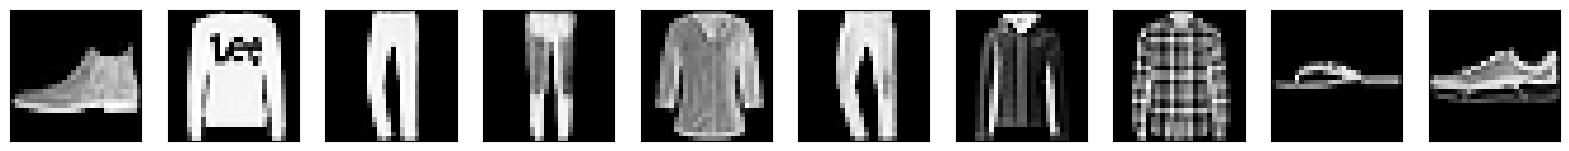

Generated:


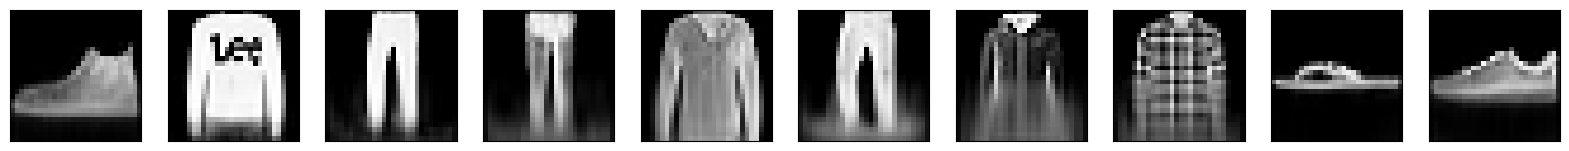

Epoch: 4 Loss_Train: 0.008663201597624938
Original:


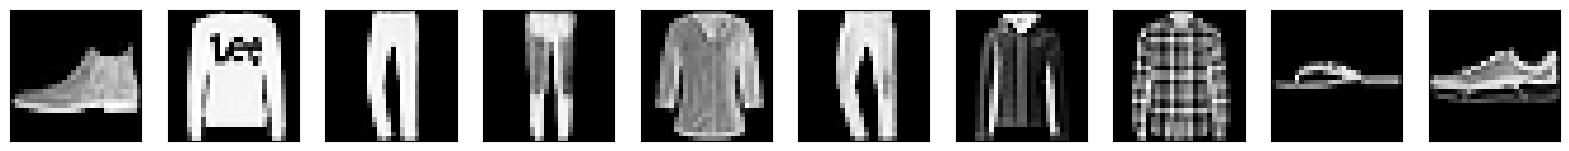

Generated:


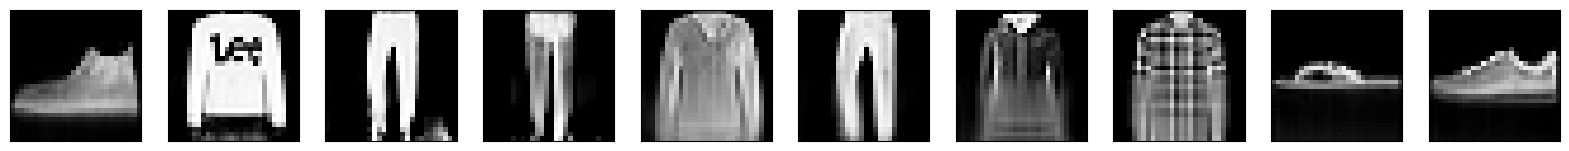

Epoch: 5 Loss_Train: 0.00862191305014031
Original:


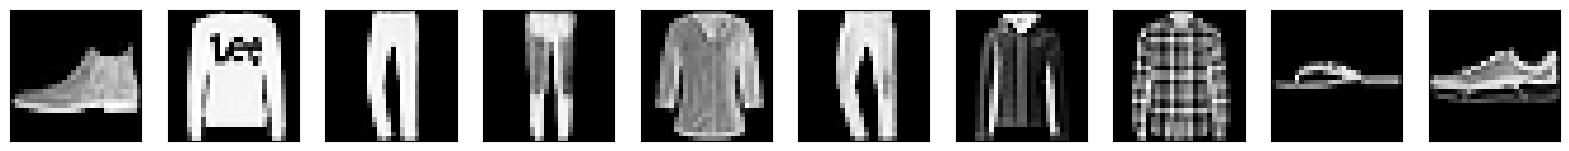

Generated:


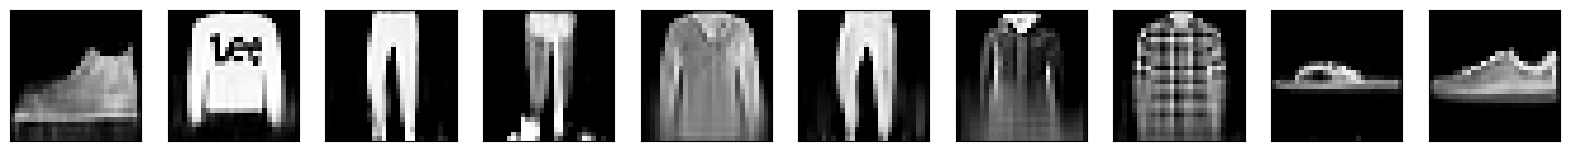

Epoch: 6 Loss_Train: 0.008576958950463658
Original:


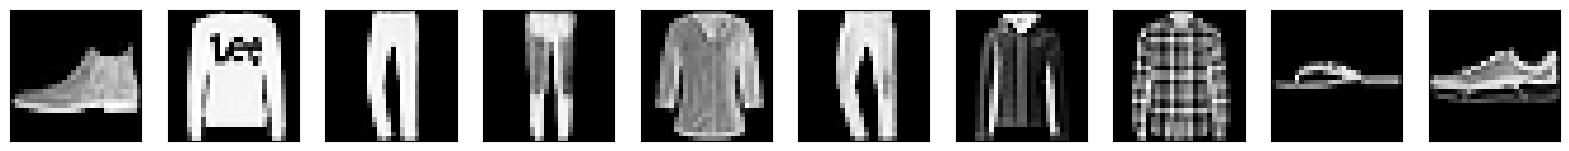

Generated:


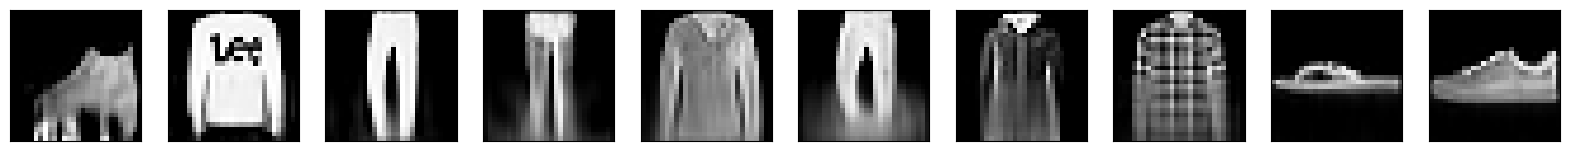

Epoch: 7 Loss_Train: 0.008538992236121869
Original:


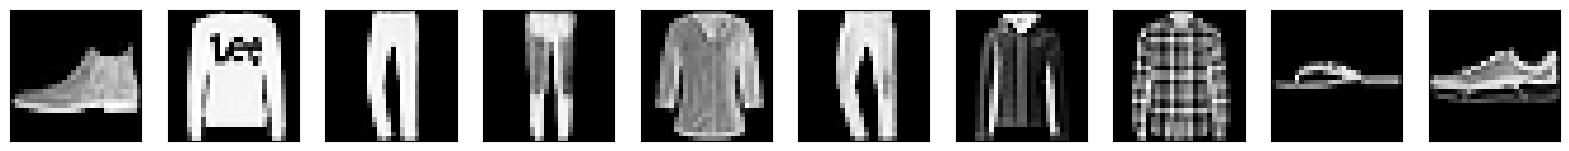

Generated:


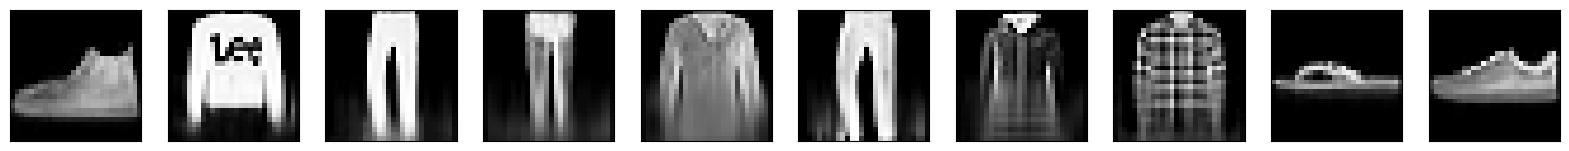

Epoch: 8 Loss_Train: 0.0085087107883577
Original:


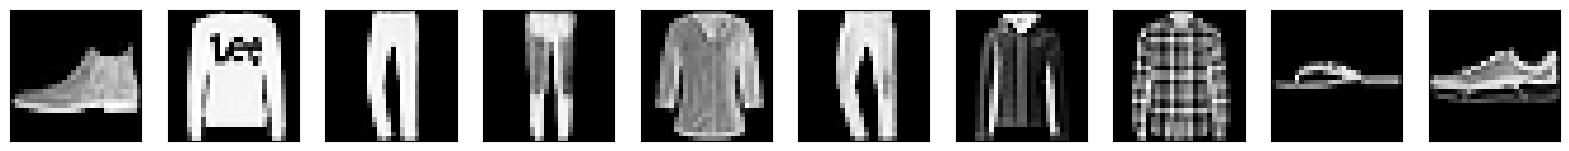

Generated:


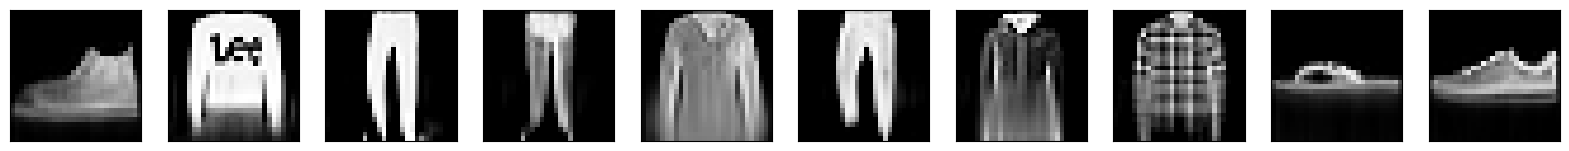

Epoch: 9 Loss_Train: 0.008468996578395825
Original:


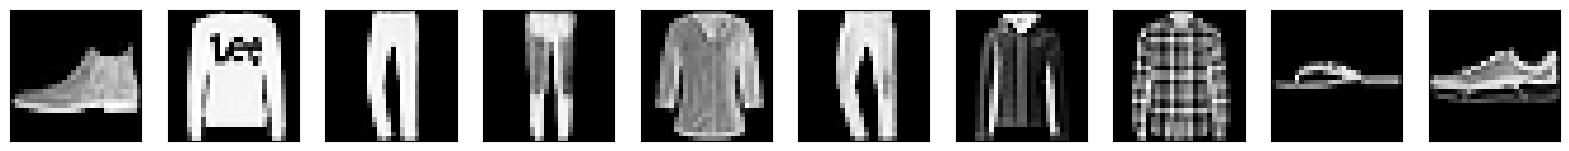

Generated:


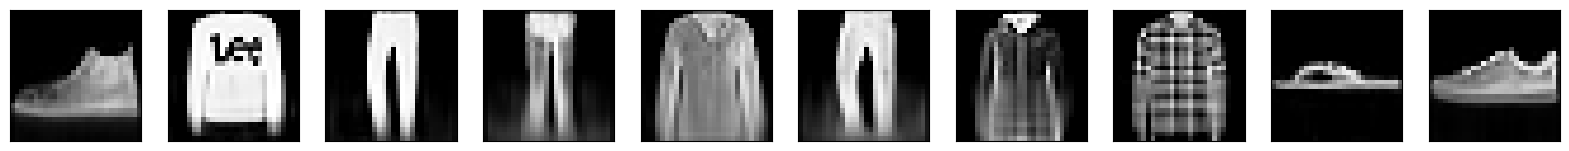

Epoch: 10 Loss_Train: 0.008436679464110568
Original:


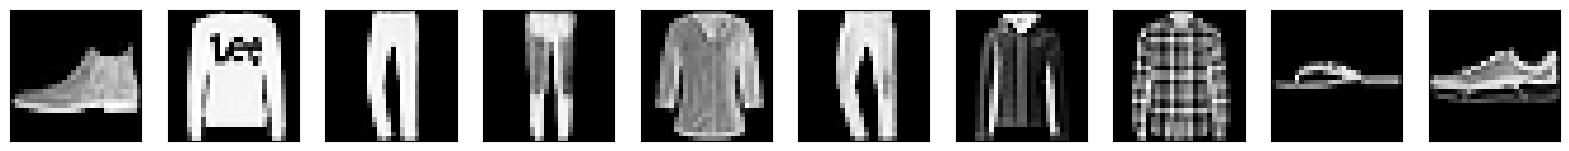

Generated:


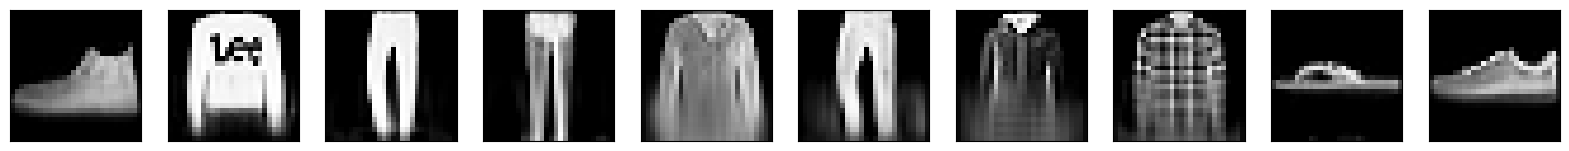

Epoch: 11 Loss_Train: 0.00840060202353487
Original:


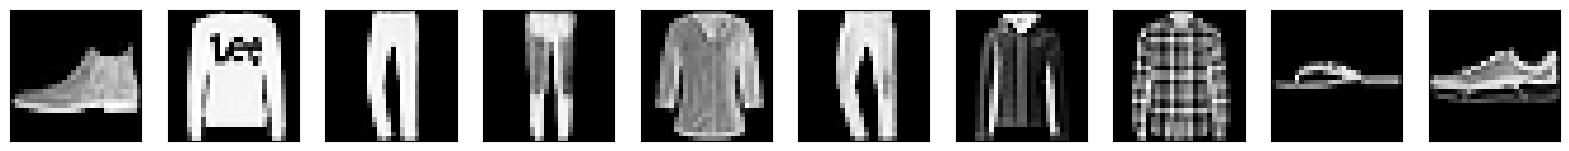

Generated:


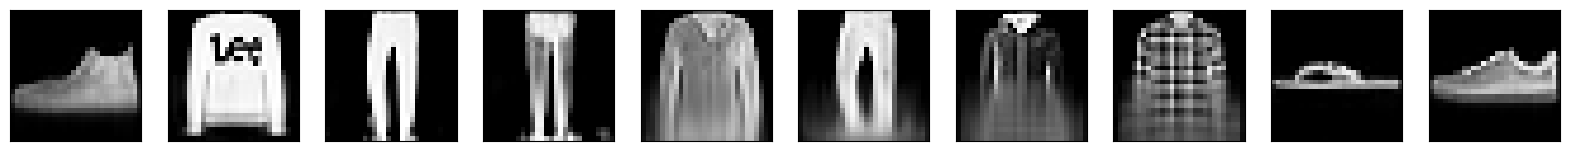

Epoch: 12 Loss_Train: 0.008378873412039982
Original:


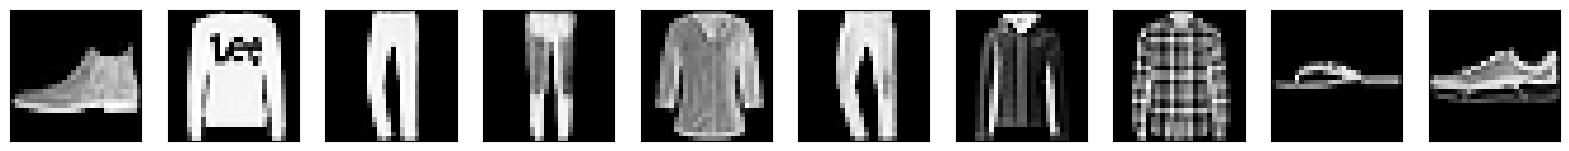

Generated:


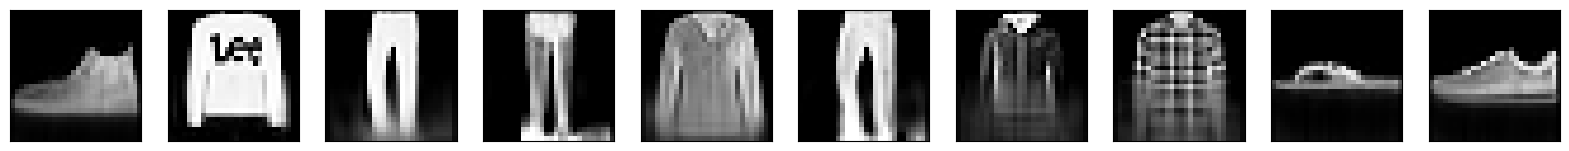

Epoch: 13 Loss_Train: 0.008342460732516535
Original:


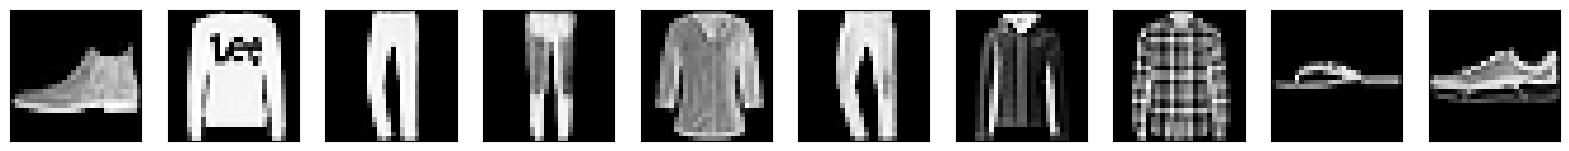

Generated:


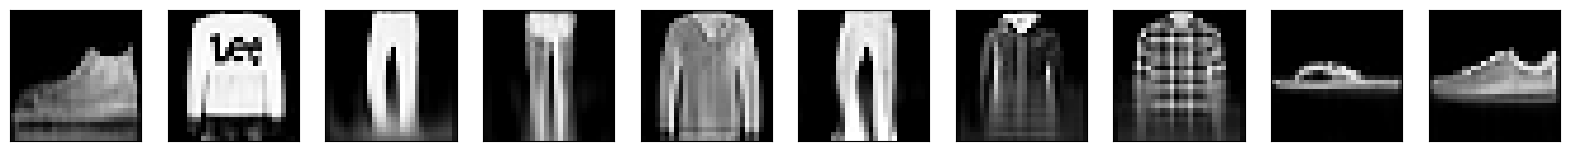

Epoch: 14 Loss_Train: 0.008316839376639597
Original:


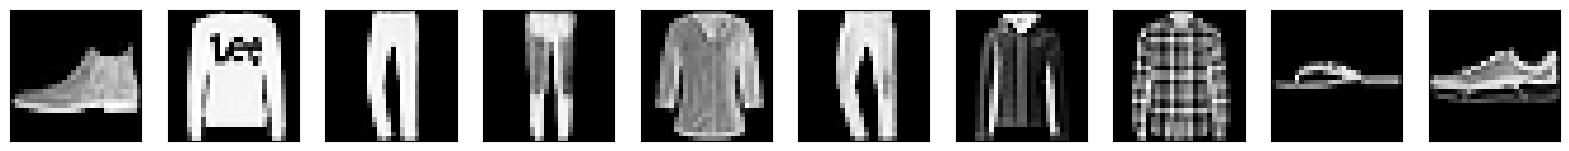

Generated:


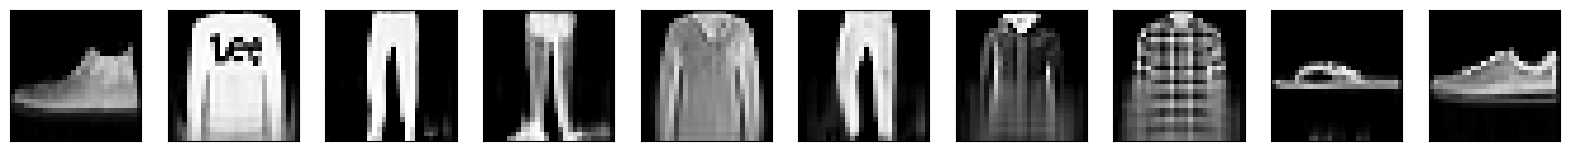

Epoch: 15 Loss_Train: 0.008288044906552678
Original:


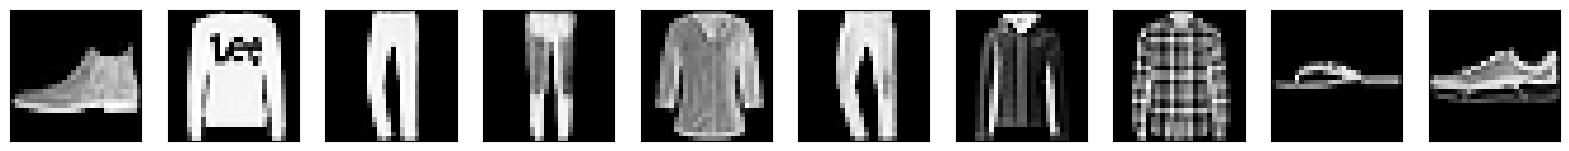

Generated:


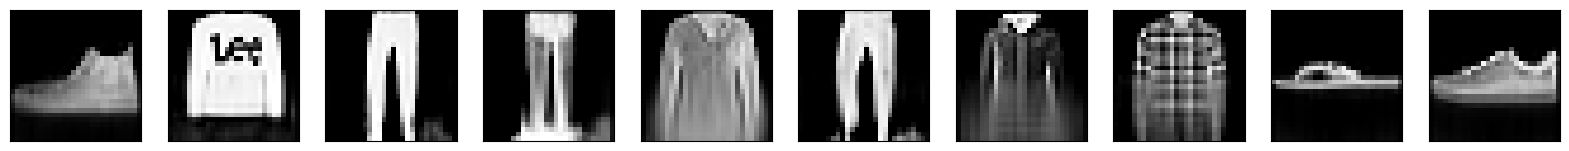

Epoch: 16 Loss_Train: 0.008253902784725655
Original:


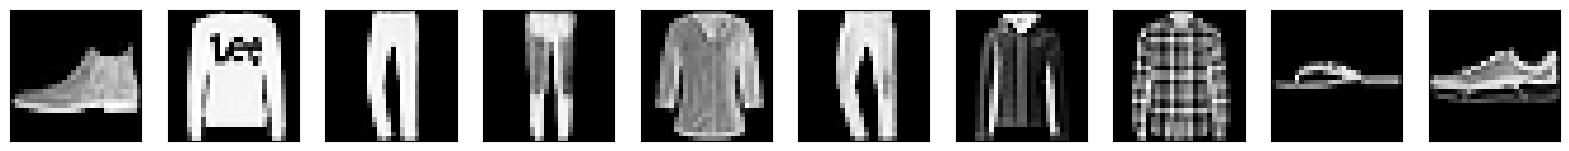

Generated:


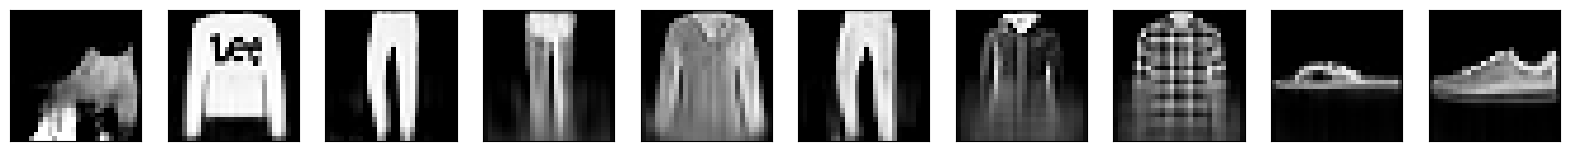

Epoch: 17 Loss_Train: 0.008242708845420225
Original:


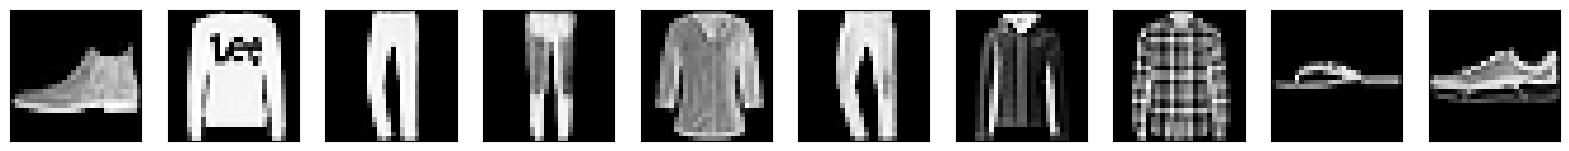

Generated:


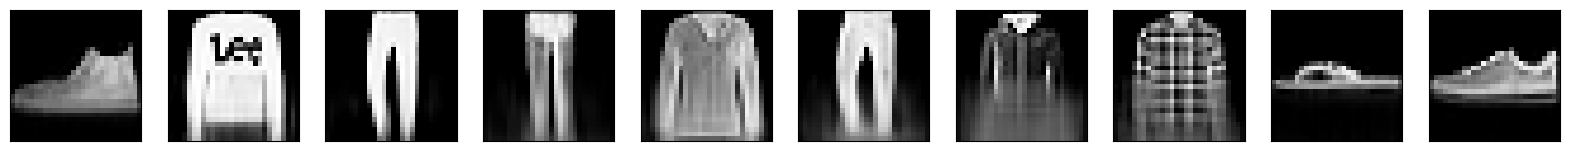

Epoch: 18 Loss_Train: 0.008202666035607405
Original:


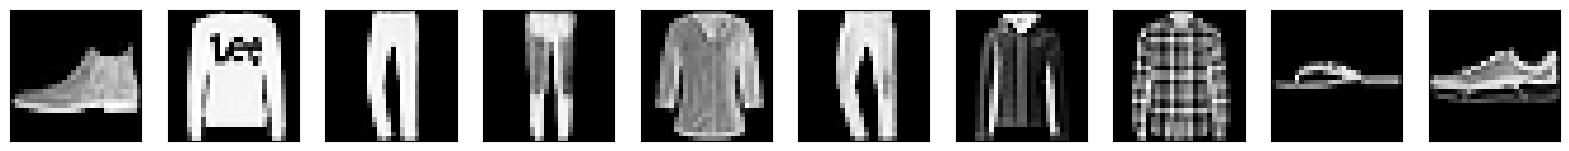

Generated:


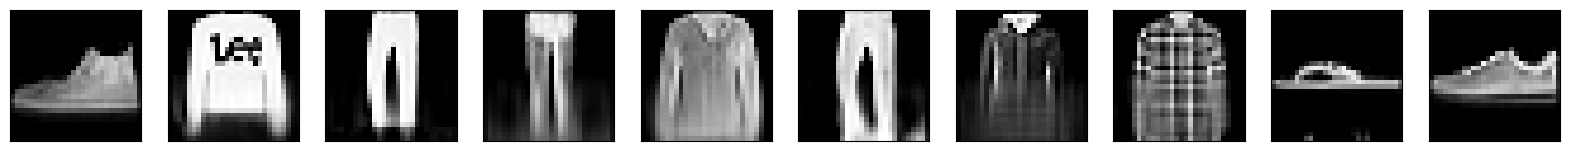

Epoch: 19 Loss_Train: 0.0081924747132303
Original:


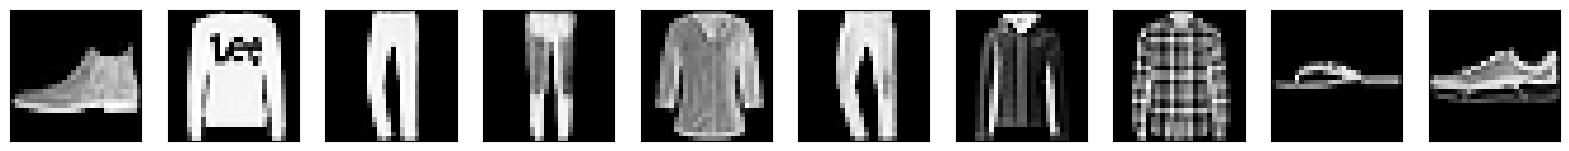

Generated:


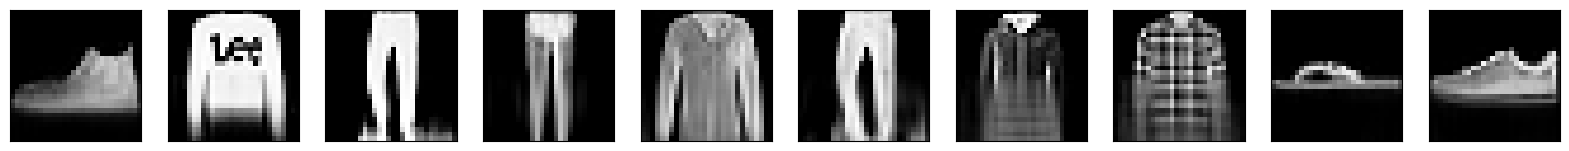

Epoch: 20 Loss_Train: 0.008157710724416737
Original:


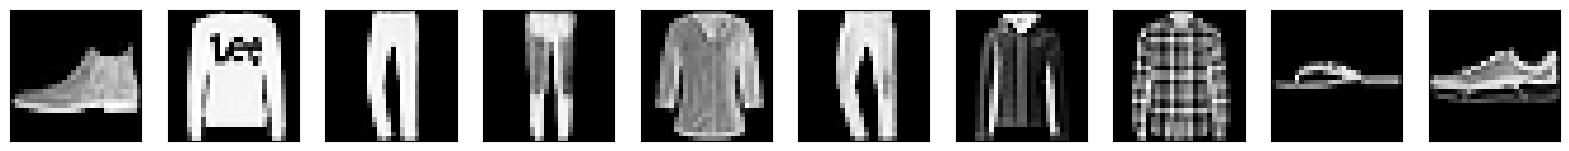

Generated:


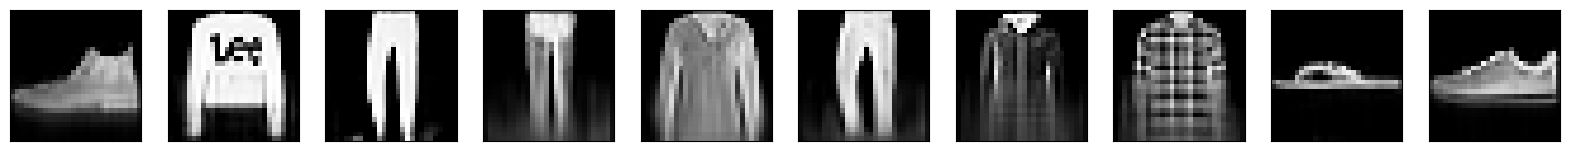

Epoch: 21 Loss_Train: 0.008130962618572872
Original:


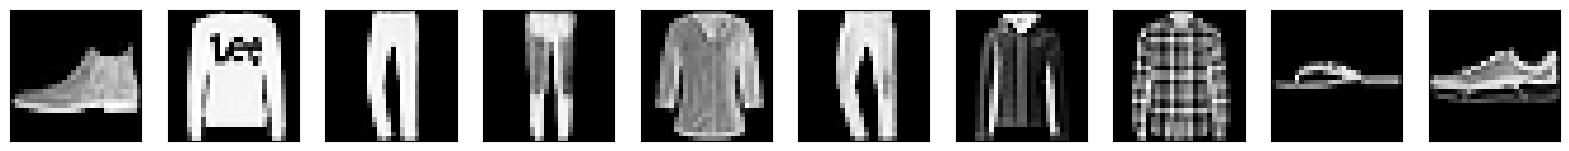

Generated:


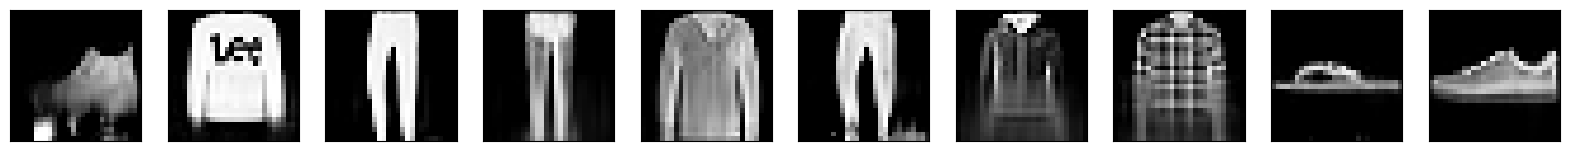

Epoch: 22 Loss_Train: 0.00811850023502037
Original:


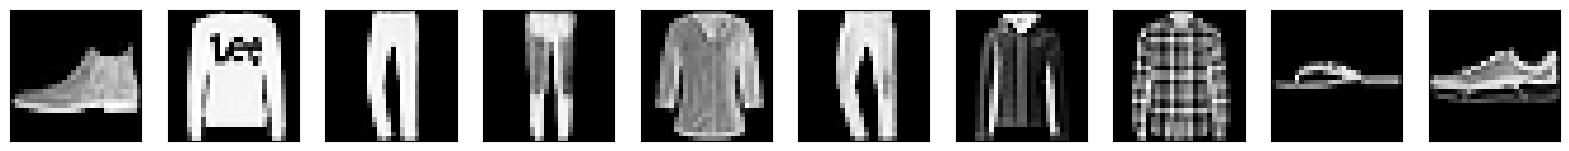

Generated:


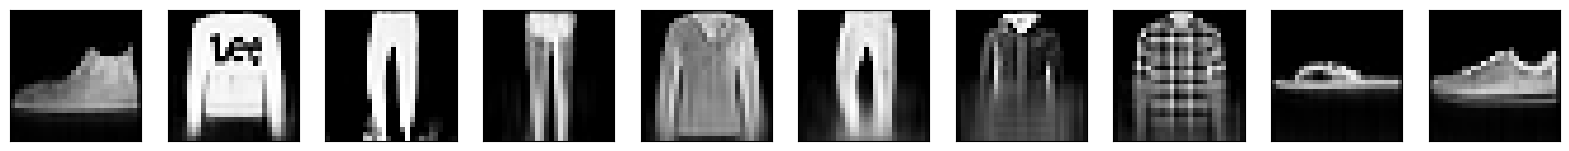

Epoch: 23 Loss_Train: 0.008089015724510068
Original:


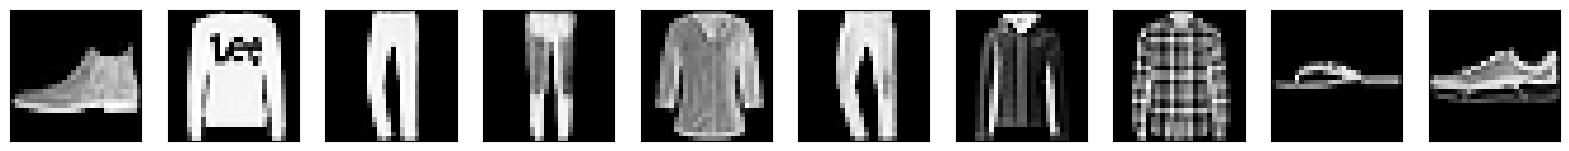

Generated:


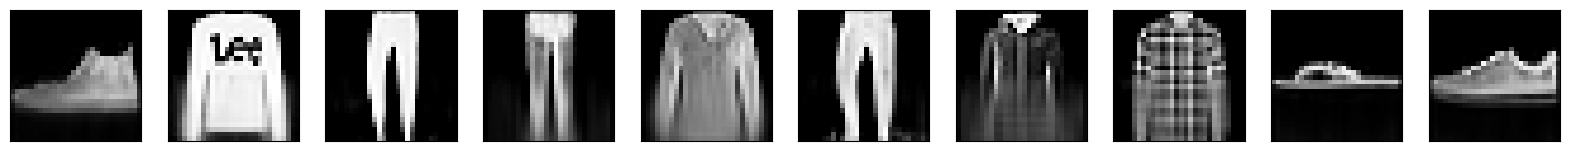

Epoch: 24 Loss_Train: 0.008075516379327513
Original:


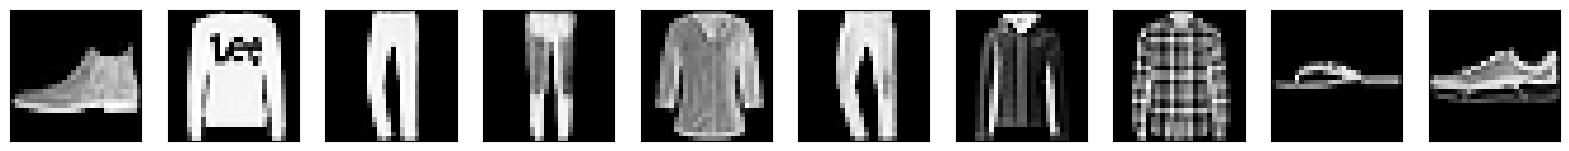

Generated:


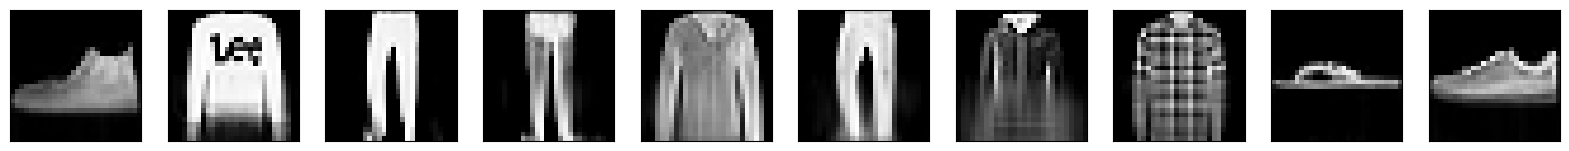

In [9]:
from torch import optim

# 損失関数: 交差エントロピー誤差関数
loss_fnc = nn.MSELoss()

# 最適化アルゴリズム: Adam
optimizer = optim.Adam(net.parameters())  # 学習率は0.01

# 損失ログ
record_loss_train = []

# 学習
for i in range(25): # 25エポック学習
    # 訓練
    net.train()
    loss_train = 0
    for j, (x, t) in enumerate(train_loader): # ミニバッチ（x, t）を取り出す
        x, t = x.cuda(), t.cuda() # GPU対応

        y = net(x)
        loss = loss_fnc(y, t)
        loss_train += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    loss_train /= j+1
    record_loss_train.append(loss_train)

    if i%1 == 0:
        print("Epoch:", i, "Loss_Train:", loss_train)
        generate_images()

# 7. 誤差の推移

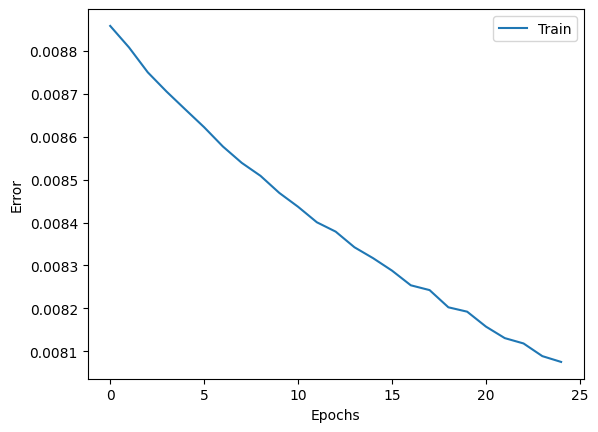

In [10]:
import matplotlib.pyplot as plt

plt.plot(range(len(record_loss_train)), record_loss_train, label="Train")
plt.legend()

plt.xlabel("Epochs")
plt.ylabel("Error")
plt.show()